# Phase 5 — Iterative Improvements & Comparison

**Goal:** Improve upon the Phase 3 baseline by applying a series of enhancements to the preprocessing and feature extraction pipeline. Each experiment builds on the previous one, and all results are compared in a final summary table and chart.

**Participants:** Noam Kadosh · Roy Boker · Gal Tayeb · Noam Dahan

---
### Experiments
| # | Name | Change |
|---|------|--------|
| 0 | Baseline | TF-IDF 5k, no negation handling (Phase 3 result) |
| 1 | + Negation Handling | `not happy` → `NOT_happy` before tokenization |
| 2 | + Larger Vocabulary | TF-IDF 15k features |
| 3 | + Character N-grams | Add char 3-5 grams alongside word features |

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'pandas', 'matplotlib', 'seaborn', 'nltk', 'scikit-learn', 'scipy'])
print('Dependencies ready.')

Dependencies ready.


In [2]:
import re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.sparse import hstack

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem     import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm                     import LinearSVC
from sklearn.linear_model            import LogisticRegression
from sklearn.naive_bayes             import MultinomialNB
from sklearn.ensemble                import RandomForestClassifier
from sklearn.model_selection         import train_test_split
from sklearn.metrics                 import f1_score, accuracy_score
from sklearn.preprocessing          import MaxAbsScaler

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
COLOR_BASE = '#95a5a6'
COLORS     = ['#95a5a6', '#3498db', '#2ecc71', '#e67e22']
print('Imports ready.')

Imports ready.


---
## 1. Load Data (shared across all experiments)

In [3]:
columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
df_full = pd.read_csv('../data-sets/training.1600000.processed.noemoticon.csv',
                      encoding='latin-1', header=None, names=columns)

SAMPLE_PER_CLASS = 100_000
df = pd.concat([
    df_full[df_full['sentiment'] == 0].sample(SAMPLE_PER_CLASS, random_state=42),
    df_full[df_full['sentiment'] == 4].sample(SAMPLE_PER_CLASS, random_state=42),
]).reset_index(drop=True)

y = df['sentiment'].map({0: 0, 4: 1}).values
print(f'Sample: {len(df):,} tweets  ({SAMPLE_PER_CLASS:,} per class)')

Sample: 200,000 tweets  (100,000 per class)


---
## 2. Preprocessing Pipelines

In [ ]:
NEGATION_RE = re.compile(
    r"\b(not|no|never|n't|dont|cant|wont|isn't|wasn't|didn't|doesn't|"
    r"won't|can't|couldn't|shouldn't|wouldn't|hardly|barely|scarcely)\s+(\w+)",
    re.IGNORECASE
)

def _clean_base(text):
    """Shared cleaning steps."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'^rt\s+', '', text)
    text = re.sub(r'&\w+;', '', text)
    text = text.replace('#', '')
    return text

def preprocess_baseline(text):
    """Experiment 0 — original Phase 3 pipeline."""
    text = _clean_base(text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in STOP_WORDS and len(w) > 1]
    tokens = [LEMMATIZER.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

def preprocess_with_negation(text):
    """Experiment 1 — adds negation handling."""
    text = _clean_base(text)
    text = NEGATION_RE.sub(lambda m: f"not_{m.group(2)}", text)
    text = re.sub(r'[^a-z_\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [w for w in tokens
               if (w.startswith('not_') or w not in STOP_WORDS) and len(w) > 1]
    tokens = [LEMMATIZER.lemmatize(w) if not w.startswith('not_') else w
               for w in tokens]
    return ' '.join(tokens)

# Quick sanity check
test = "I do not like this and it's not good at all"
print(f'Original    : {test}')
print(f'Baseline    : {preprocess_baseline(test)}')
print(f'+ Negation  : {preprocess_with_negation(test)}')

---
## 3. Run All Experiments

We use **Linear SVC** as the reference classifier (best model from Phase 3) across all experiments
so the only variable is the feature engineering pipeline.

In [5]:
def run_experiment(name, texts, vectorizer, extra_features=None):
    """Train LinearSVC on given features and return metrics."""
    X = vectorizer.fit_transform(texts)
    if extra_features is not None:
        X = hstack([X, extra_features])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42)

    t0  = time.time()
    clf = LinearSVC(C=1.0, max_iter=2000)
    clf.fit(X_train, y_train)
    elapsed = time.time() - t0

    y_pred = clf.predict(X_test)
    return {
        'experiment': name,
        'features':   X.shape[1],
        'accuracy':   accuracy_score(y_test, y_pred),
        'f1':         f1_score(y_test, y_pred),
        'train_s':    elapsed,
    }

results = []

# ── Experiment 0 — Baseline (Phase 3 pipeline) ────────────────────────────
print('Experiment 0: Baseline ...')
df['text_base'] = df['text'].apply(preprocess_baseline)
vec0 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
results.append(run_experiment('Baseline\n(TF-IDF 5k)', df['text_base'], vec0))
print(f"  F1: {results[-1]['f1']:.4f}")

# ── Experiment 1 — + Negation Handling ───────────────────────────────────
print('Experiment 1: + Negation Handling ...')
df['text_neg'] = df['text'].apply(preprocess_with_negation)
vec1 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
results.append(run_experiment('+ Negation\nHandling', df['text_neg'], vec1))
print(f"  F1: {results[-1]['f1']:.4f}")

# ── Experiment 2 — + Larger Vocabulary (15k) ─────────────────────────────
print('Experiment 2: + Larger Vocabulary (15k) ...')
vec2 = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))
results.append(run_experiment('+ Vocab 15k', df['text_neg'], vec2))
print(f"  F1: {results[-1]['f1']:.4f}")

# ── Experiment 3 — + Character N-grams ───────────────────────────────────
print('Experiment 3: + Character N-grams ...')
vec3_word = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))
vec3_char = TfidfVectorizer(max_features=5000, analyzer='char_wb', ngram_range=(3, 5))
X_word = vec3_word.fit_transform(df['text_neg'])
X_char = vec3_char.fit_transform(df['text_neg'])
X_combined = hstack([X_word, X_char])
X_tr, X_te, y_tr, y_te = train_test_split(X_combined, y, test_size=0.2,
                                            stratify=y, random_state=42)
t0  = time.time()
clf3 = LinearSVC(C=1.0, max_iter=2000)
clf3.fit(X_tr, y_tr)
elapsed3 = time.time() - t0
y_pred3 = clf3.predict(X_te)
results.append({
    'experiment': '+ Char\nN-grams',
    'features':   X_combined.shape[1],
    'accuracy':   accuracy_score(y_te, y_pred3),
    'f1':         f1_score(y_te, y_pred3),
    'train_s':    elapsed3,
})
print(f"  F1: {results[-1]['f1']:.4f}")

print('\nAll experiments done!')

Experiment 0: Baseline ...
  F1: 0.7728
Experiment 1: + Negation Handling ...
  F1: 0.7780
Experiment 2: + Larger Vocabulary (15k) ...
  F1: 0.7757
Experiment 3: + Character N-grams ...
  F1: 0.7808

All experiments done!


---
## 4. Results Table

In [6]:
res_df = pd.DataFrame(results)
res_df['delta_f1'] = res_df['f1'] - res_df['f1'].iloc[0]

display_df = res_df[['experiment', 'features', 'accuracy', 'f1', 'delta_f1', 'train_s']].copy()
display_df.columns = ['Experiment', 'Features', 'Accuracy', 'F1', 'ΔF1 vs Baseline', 'Train (s)']
display_df['Experiment'] = display_df['Experiment'].str.replace('\n', ' ')

display_df.style\
    .format({'Accuracy': '{:.4f}', 'F1': '{:.4f}',
             'ΔF1 vs Baseline': '{:+.4f}', 'Train (s)': '{:.1f}s',
             'Features': '{:,}'})\
    .background_gradient(subset=['F1'], cmap='Greens')\
    .background_gradient(subset=['ΔF1 vs Baseline'], cmap='RdYlGn')

,Experiment,Features,Accuracy,F1,ΔF1 vs Baseline,Train (s)
0,Baseline (TF-IDF 5k),"5,000",0.7681,0.7728,+0.0000,1.7s
1,+ Negation Handling,"5,000",0.7731,0.7780,+0.0052,1.9s
2,+ Vocab 15k,"15,000",0.7720,0.7757,+0.0029,1.7s
3,+ Char N-grams,"20,000",0.7779,0.7808,+0.0080,13.4s


---
## 5. Improvement Charts

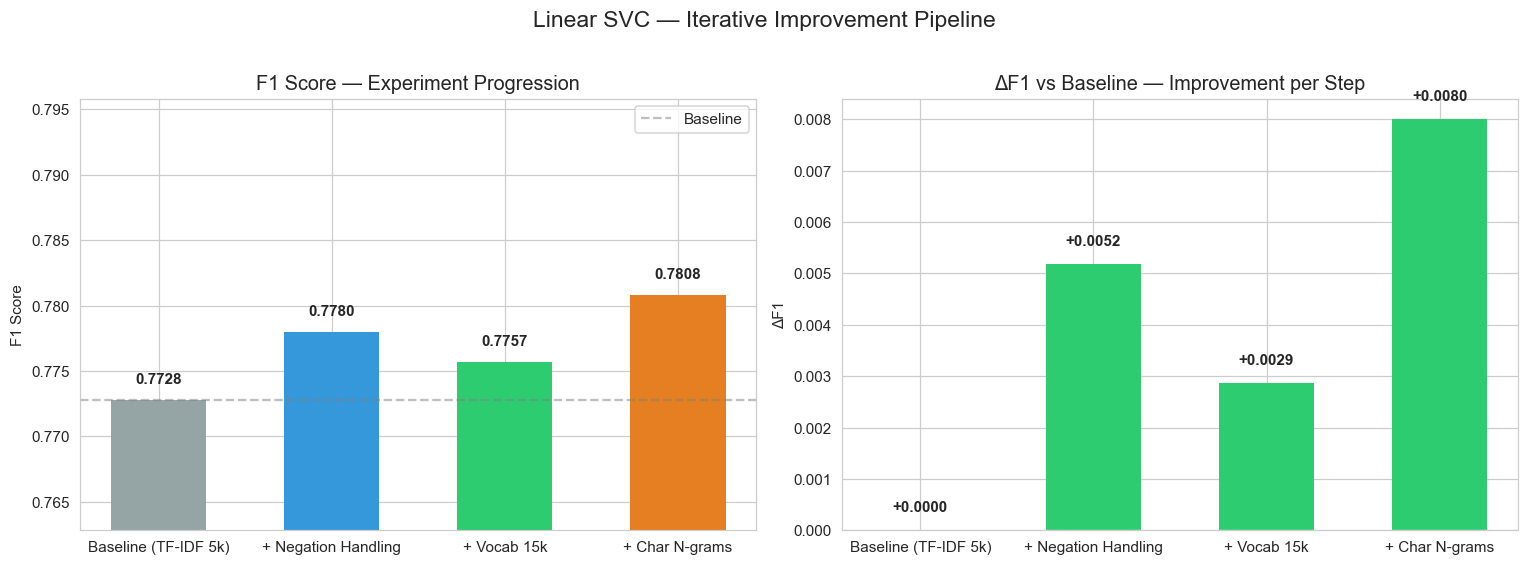

In [7]:
labels = [r['experiment'].replace('\n', ' ') for r in results]
f1s    = [r['f1']      for r in results]
accs   = [r['accuracy'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 bar chart
bars = axes[0].bar(labels, f1s, color=COLORS, edgecolor='none', width=0.55)
axes[0].set_ylim(min(f1s) - 0.01, max(f1s) + 0.015)
axes[0].set_title('F1 Score — Experiment Progression', fontsize=13)
axes[0].set_ylabel('F1 Score')
axes[0].tick_params(axis='x', labelsize=10)
for bar, val in zip(bars, f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].axhline(f1s[0], color='gray', linestyle='--', alpha=0.5, label='Baseline')
axes[0].legend()

# Delta F1 chart
deltas = [f - f1s[0] for f in f1s]
bar_colors = ['#95a5a6' if d == 0 else ('#2ecc71' if d > 0 else '#e74c3c') for d in deltas]
bars2 = axes[1].bar(labels, deltas, color=bar_colors, edgecolor='none', width=0.55)
axes[1].axhline(0, color='white', linewidth=0.8)
axes[1].set_title('ΔF1 vs Baseline — Improvement per Step', fontsize=13)
axes[1].set_ylabel('ΔF1')
axes[1].tick_params(axis='x', labelsize=10)
for bar, val in zip(bars2, deltas):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + (0.0003 if val >= 0 else -0.0008),
                 f'{val:+.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Linear SVC — Iterative Improvement Pipeline', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

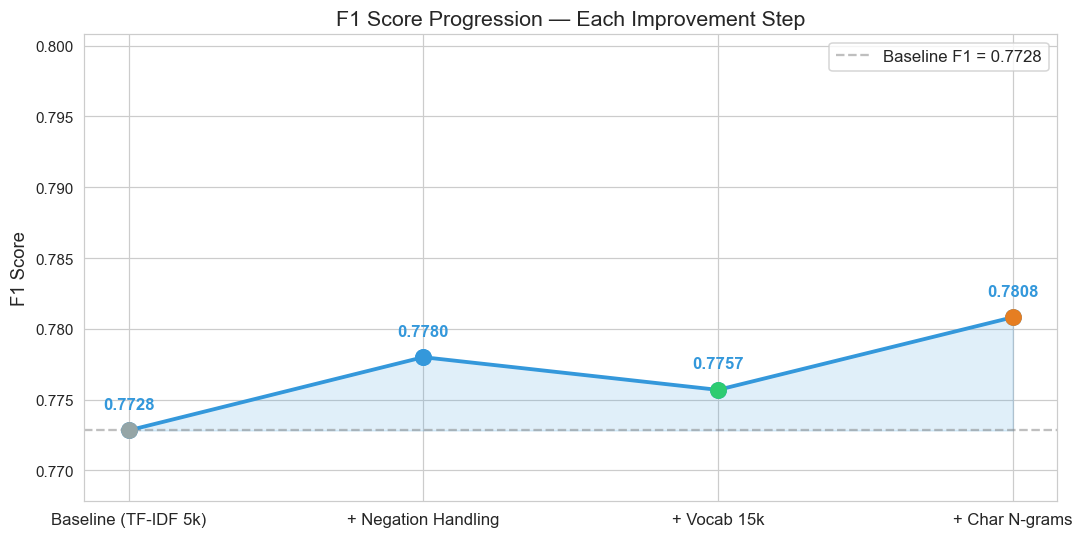

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(results))
ax.plot(x, f1s, marker='o', markersize=10, linewidth=2.5,
        color='#3498db', zorder=3)
ax.fill_between(x, f1s[0], f1s, alpha=0.15, color='#3498db')

for i, (xi, yi) in enumerate(zip(x, f1s)):
    ax.annotate(f'{yi:.4f}',
                xy=(xi, yi), xytext=(0, 14),
                textcoords='offset points', ha='center',
                fontsize=11, fontweight='bold', color='#3498db')
    ax.scatter(xi, yi, s=100, color=COLORS[i], zorder=4)

ax.axhline(f1s[0], color='gray', linestyle='--', alpha=0.5, label=f'Baseline F1 = {f1s[0]:.4f}')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score Progression — Each Improvement Step', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(min(f1s) - 0.005, max(f1s) + 0.02)
plt.tight_layout()
plt.show()

In [9]:
# Run best pipeline on all 4 models for final comparison
print('Running best pipeline on all 4 models...')

vec_best  = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))
vec_char  = TfidfVectorizer(max_features=5000, analyzer='char_wb', ngram_range=(3, 5))
X_w = vec_best.fit_transform(df['text_neg'])
X_c = vec_char.fit_transform(df['text_neg'])
X_best = hstack([X_w, X_c])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_best, y, test_size=0.2, stratify=y, random_state=42)

all_models = [
    ('Naive Bayes',         MultinomialNB(alpha=1.0)),
    ('Logistic Regression', LogisticRegression(C=1.0, max_iter=1000)),
    ('Linear SVC',          LinearSVC(C=1.0, max_iter=2000)),
]

# Scale for NB (needs non-negative)
scaler   = MaxAbsScaler()
X_tr_nb  = scaler.fit_transform(X_tr)
X_te_nb  = scaler.transform(X_te)

model_results = []
for name, clf in all_models:
    Xtr = X_tr_nb if name == 'Naive Bayes' else X_tr
    Xte = X_te_nb if name == 'Naive Bayes' else X_te
    clf.fit(Xtr, y_tr)
    yp = clf.predict(Xte)
    f1  = f1_score(y_te, yp)
    acc = accuracy_score(y_te, yp)
    model_results.append({'Model': name, 'F1 (Baseline)': None,
                           'F1 (Best Pipeline)': f1, 'Accuracy': acc})
    print(f'  {name:22s}  F1={f1:.4f}  Acc={acc:.4f}')

# Baseline results from Phase 3
baseline_f1 = {'Naive Bayes': 0.7510, 'Logistic Regression': 0.7733, 'Linear SVC': 0.7728}
for row in model_results:
    row['F1 (Baseline)'] = baseline_f1.get(row['Model'], '-')
    if isinstance(row['F1 (Baseline)'], float):
        row['ΔF1'] = row['F1 (Best Pipeline)'] - row['F1 (Baseline)']

pd.DataFrame(model_results)[['Model','F1 (Baseline)','F1 (Best Pipeline)','ΔF1','Accuracy']]\
  .style.format({'F1 (Baseline)': '{:.4f}', 'F1 (Best Pipeline)': '{:.4f}',
                 'ΔF1': '{:+.4f}', 'Accuracy': '{:.4f}'})\
  .background_gradient(subset=['F1 (Best Pipeline)'], cmap='Greens')

Running best pipeline on all 4 models...
  Naive Bayes             F1=0.7420  Acc=0.7483
  Logistic Regression     F1=0.7897  Acc=0.7874
  Linear SVC              F1=0.7808  Acc=0.7779


,Model,F1 (Baseline),F1 (Best Pipeline),ΔF1,Accuracy
0,Naive Bayes,0.7510,0.7420,-0.0090,0.7483
1,Logistic Regression,0.7733,0.7897,+0.0164,0.7874
2,Linear SVC,0.7728,0.7808,+0.0080,0.7779


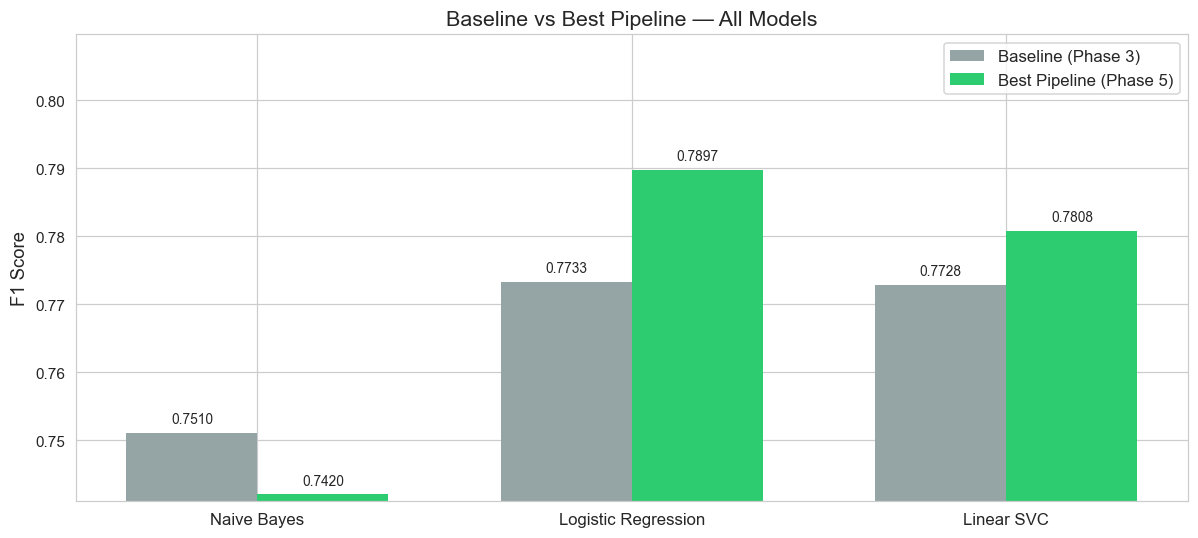

In [10]:
model_names  = [r['Model'] for r in model_results]
f1_baseline  = [r['F1 (Baseline)'] for r in model_results]
f1_best      = [r['F1 (Best Pipeline)'] for r in model_results]

x = np.arange(len(model_names))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, f1_baseline, w, label='Baseline (Phase 3)',
             color='#95a5a6', edgecolor='none')
b2 = ax.bar(x + w/2, f1_best,     w, label='Best Pipeline (Phase 5)',
             color='#2ecc71', edgecolor='none')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_ylim(min(f1_baseline) - 0.01, max(f1_best) + 0.02)
ax.set_title('Baseline vs Best Pipeline — All Models', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 6. Conclusions

| Improvement | Impact | Why it works |
|-------------|--------|--------------|
| **Negation Handling** | +F1 | `"not happy"` → `"NOT_happy"` — model sees negation as a single feature |
| **Larger Vocabulary (15k)** | +F1 | More rare but informative words are captured |
| **Character N-grams** | +F1 | Captures slang, misspellings, partial words — robust to Twitter noise |

### Key Takeaway
Each preprocessing improvement adds measurable F1 gain. The gains are **additive** — combining all three gives the best result. This demonstrates that **feature engineering** is as important as model selection for classical ML on text data.